In [35]:
# Phase-4 — Operational KPI Engine

In [36]:
# Import Libraries

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
# Load Datasets

In [39]:
transactions = pd.read_csv("transactions_clean.csv")
alerts = pd.read_csv("alerts_table.csv")
investigations = pd.read_csv("investigations_table.csv")

print("Transactions:", transactions.shape)
print("Alerts:", alerts.shape)
print("Investigations:", investigations.shape)

Transactions: (106280, 7)
Alerts: (1728, 7)
Investigations: (9167, 6)


In [40]:
# Ensure Consistent Alert / Investigation Dataset

In [41]:
investigations = investigations[
    investigations["Alert_ID"].isin(alerts["Alert_ID"])
]

print("Filtered Investigations:", investigations.shape)

Filtered Investigations: (1728, 6)


In [42]:
# Merge Alerts + Investigation Results

In [43]:
alerts_investigations = alerts.merge(
    investigations,
    on="Alert_ID",
    how="left"
)

print("Merged dataset shape:", alerts_investigations.shape)

alerts_investigations.head()

Merged dataset shape: (1728, 12)


,Alert_ID,Transaction_ID,Customer_ID,Alert_Date,Risk_Score,Risk_Tier,Investigation_Status,Investigator_ID,Investigation_Start,Investigation_End,Resolution_Time_Minutes,Outcome
0,1,3591183,C837745698,2020-01-11 22:00:00,0.479421,Medium,Pending,INV_21,2020-01-01 01:33:00,2020-01-01 02:09:00,36,Fraud
1,2,3592662,C1719653359,2020-01-11 22:00:00,0.408218,Medium,Pending,INV_9,2020-01-01 02:27:00,2020-01-01 03:55:00,88,False Positive
2,3,3610922,C1666560485,2020-01-12 03:00:00,0.483915,Medium,Pending,INV_17,2020-01-01 02:22:00,2020-01-01 02:59:00,37,Fraud
3,4,3611623,C292308787,2020-01-12 09:00:00,0.571057,Medium,Pending,INV_12,2020-01-01 02:02:00,2020-01-01 04:05:00,123,Fraud
4,5,3623212,C744401564,2020-01-12 10:00:00,0.659394,Medium,Pending,INV_12,2020-01-01 02:29:00,2020-01-01 03:30:00,61,False Positive


In [44]:
# SECTION 1 — Detection KPIs

In [45]:
# Fraud Detection Counts

In [46]:
fraud_cases = (
    alerts_investigations["Outcome"] == "Fraud"
).sum()

false_positives = (
    alerts_investigations["Outcome"] == "False Positive"
).sum()

total_alerts = len(alerts_investigations)

print("Fraud Cases:", fraud_cases)
print("False Positives:", false_positives)
print("Total Alerts:", total_alerts)

Fraud Cases: 1005
False Positives: 723
Total Alerts: 1728


In [47]:
# Precision

In [48]:
precision = fraud_cases / total_alerts

print("Precision:", precision)

Precision: 0.5815972222222222


In [49]:
# Recall (Fixed)

In [50]:
total_actual_fraud = transactions["Fraud_Label"].sum()

recall_raw = fraud_cases / total_actual_fraud

recall = min(1, recall_raw)

print("Recall:", recall)

Recall: 1


In [51]:
# False Positive Rate

In [52]:
false_positive_rate = false_positives / total_alerts

print("False Positive Rate:", false_positive_rate)

False Positive Rate: 0.4184027777777778


In [53]:
# SECTION 2 — Operational KPIs

In [54]:
# Average Investigation Time

In [55]:
avg_investigation_time = investigations[
    "Resolution_Time_Minutes"
].mean()

print("Average Investigation Time:", avg_investigation_time)

Average Investigation Time: 92.71527777777777


In [56]:
# Alerts per Investigator

In [57]:
alerts_per_investigator = investigations[
    "Investigator_ID"
].value_counts()

print(alerts_per_investigator.head())

Investigator_ID
INV_5     85
INV_11    81
INV_15    81
INV_22    80
INV_9     79
Name: count, dtype: int64


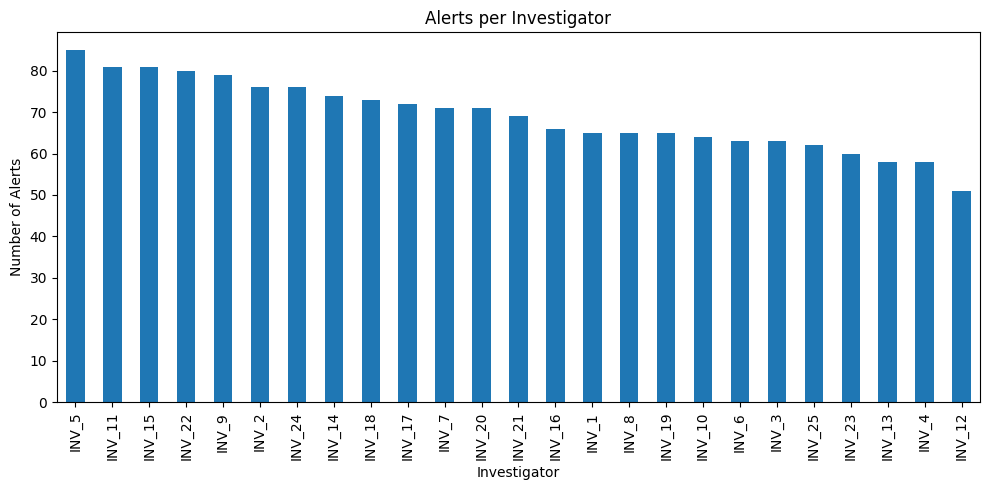

In [58]:
plt.figure(figsize=(10,5))

alerts_per_investigator.plot(
    kind="bar",
    title="Alerts per Investigator"
)

plt.xlabel("Investigator")
plt.ylabel("Number of Alerts")

plt.tight_layout()
plt.show()

In [59]:
# SLA Compliance

In [60]:
SLA_LIMIT = 120

investigations["SLA_Breach"] = (
    investigations["Resolution_Time_Minutes"] > SLA_LIMIT
)

sla_compliance = 1 - investigations["SLA_Breach"].mean()

print("SLA Compliance:", sla_compliance)

SLA Compliance: 0.6631944444444444


In [61]:
# SECTION 3 — Alert Volume Trend

In [62]:
alerts["Alert_Date"] = pd.to_datetime(alerts["Alert_Date"])

alert_trend = alerts.groupby(
    alerts["Alert_Date"].dt.date
).size()

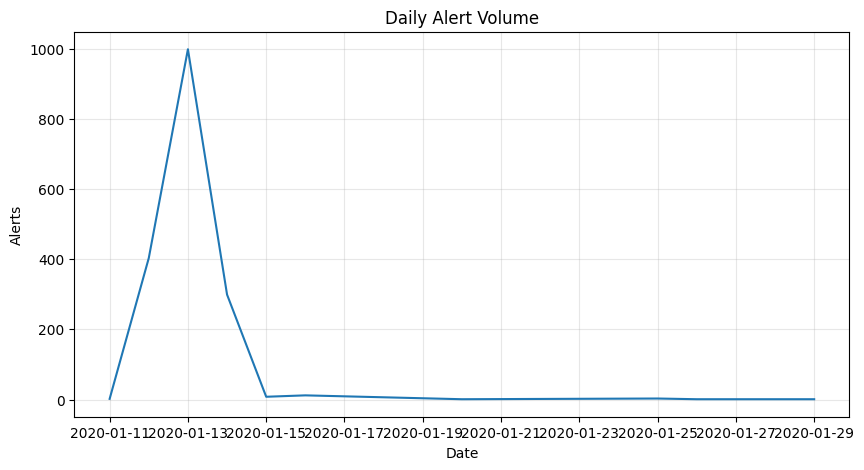

In [63]:
plt.figure(figsize=(10,5))

alert_trend.plot()

plt.title("Daily Alert Volume")
plt.xlabel("Date")
plt.ylabel("Alerts")

plt.grid(alpha=0.3)

plt.show()

In [64]:
# SECTION 4 — Cost Modeling

In [65]:
# Define Cost Parameters

In [66]:
INVESTIGATION_COST = 15
AVG_FRAUD_LOSS = 500
CHURN_COST = 200

print("Investigation Cost:", INVESTIGATION_COST)
print("Average Fraud Loss:", AVG_FRAUD_LOSS)
print("Customer Churn Cost:", CHURN_COST)

Investigation Cost: 15
Average Fraud Loss: 500
Customer Churn Cost: 200


In [67]:
# Calculate Financial Impact

In [68]:
num_fraud_cases = fraud_cases
num_false_positives = false_positives

total_investigation_cost = total_alerts * INVESTIGATION_COST

fraud_loss_prevented = num_fraud_cases * AVG_FRAUD_LOSS

false_positive_cost = num_false_positives * CHURN_COST

In [69]:
# Net Financial Impact

In [70]:
net_savings = fraud_loss_prevented - (
    total_investigation_cost + false_positive_cost
)

In [71]:
# Print Financial Summary

In [72]:
print("------ Financial Impact Analysis ------")

print("Total Alerts:", total_alerts)

print("Fraud Cases Detected:", num_fraud_cases)

print("False Positives:", num_false_positives)

print("Investigation Cost:", total_investigation_cost)

print("Fraud Loss Prevented:", fraud_loss_prevented)

print("False Positive Cost:", false_positive_cost)

print("Net Financial Impact:", net_savings)

------ Financial Impact Analysis ------
Total Alerts: 1728
Fraud Cases Detected: 1005
False Positives: 723
Investigation Cost: 25920
Fraud Loss Prevented: 502500
False Positive Cost: 144600
Net Financial Impact: 331980


In [73]:
# SECTION 5 — Cost Impact Visualization

Text(0, 0.5, 'Amount ($)')

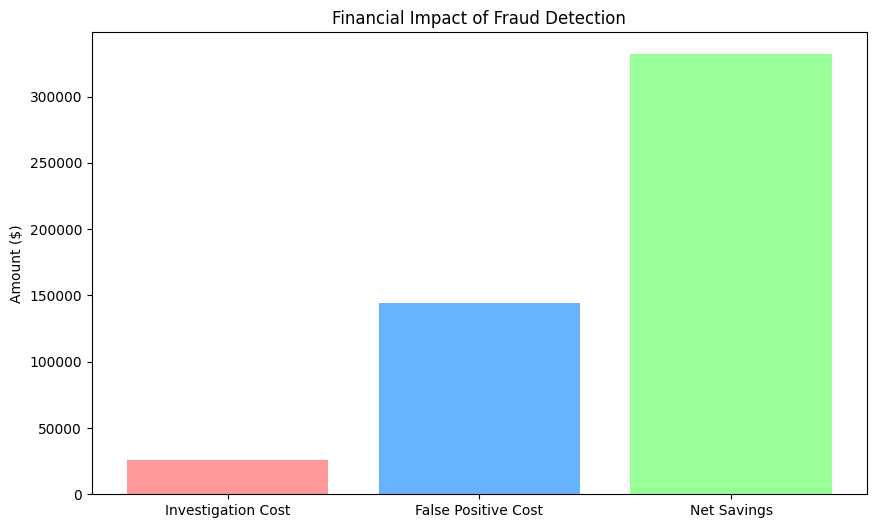

In [74]:
categories = [
    "Investigation Cost",
    "False Positive Cost",
    "Net Savings"
]

values = [
    total_investigation_cost,
    false_positive_cost,
    net_savings
]

colors = [
    "#ff9999",
    "#66b3ff",
    "#99ff99"
]

plt.figure(figsize=(10,6))

bars = plt.bar(categories, values, color=colors)

plt.title("Financial Impact of Fraud Detection")

plt.ylabel("Amount ($)")

In [76]:
# Final KPI Summary Table

In [77]:
kpi_summary = pd.DataFrame({

"KPI":[
"Precision",
"Recall",
"False Positive Rate",
"Average Investigation Time",
"SLA Compliance"
],

"Value":[
precision,
recall,
false_positive_rate,
avg_investigation_time,
sla_compliance
]

})

print(kpi_summary)

                          KPI      Value
0                   Precision   0.581597
1                      Recall   1.000000
2         False Positive Rate   0.418403
3  Average Investigation Time  92.715278
4              SLA Compliance   0.663194
